# **NAIVE BAYES CLASSIFIER:-**
 - ITS A SUPERVISED MACHINE LEARNING ALGORITHM,BASED ON THE CONCEPT OF BAYES THEOREM,USED FOR CLASSIFICATION TASK.
 - IT ASSUMES EVERY FEATURES AS INDEPENDENT.
 - IT CLASSIFIES DATA ELEMENTS BASED ON THE PROBABLITY VALUES CALCULATED USING PROPR KNOWLEDGE.


In [1]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


## **IMPORTING REQUIRED LIBRARIES:-**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import *
from sklearn.metrics import *

## **READING THE DATASET:-**

In [3]:
df=pd.read_csv('heart.csv')
df.head(6)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1


## **EDA PROCESS:-**

In [4]:
df.isnull().sum() # checking for null values

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
df.duplicated().sum() # checking for duplicate values

np.int64(1)

In [7]:
df[df.duplicated()]# showing the duplicate values

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [8]:
# Deleting of the duplicate valueS:-
df.drop_duplicates(inplace=True)

In [10]:
c=df.corr()
c # correlation between veriables

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


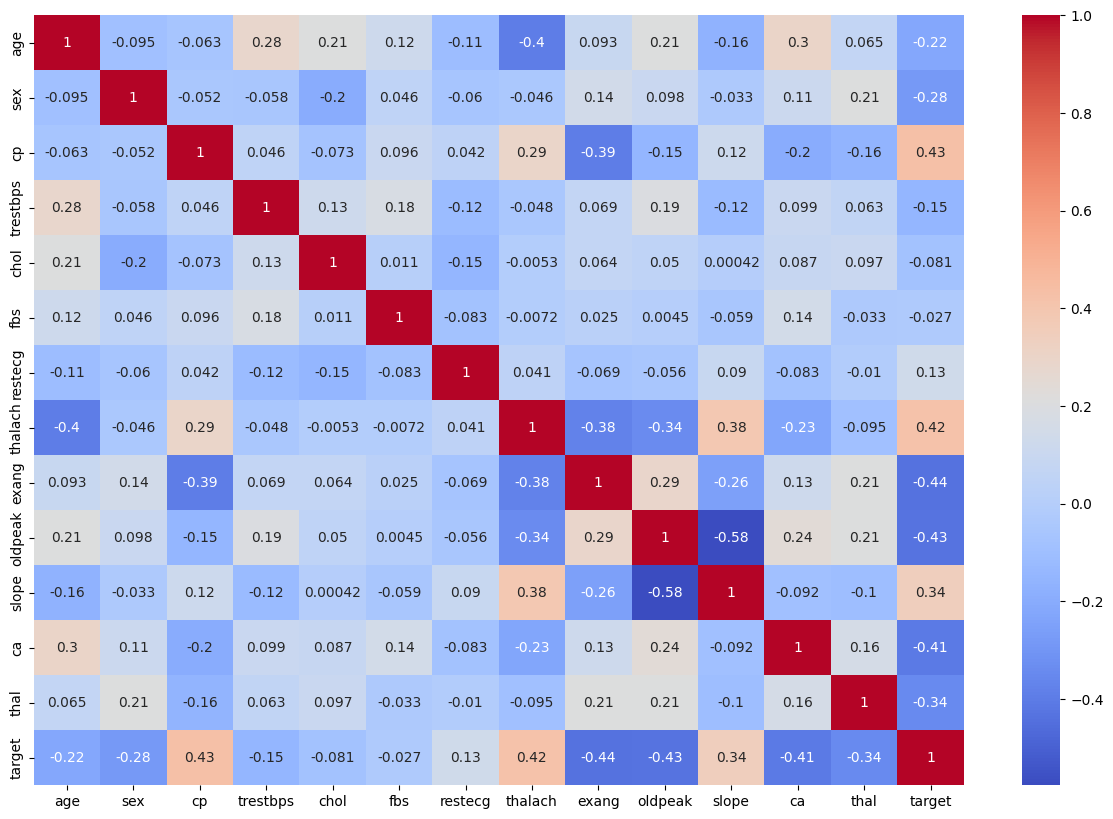

In [13]:
plt.figure(figsize=(15,10))
sns.heatmap(c,annot=True,cmap='coolwarm')
plt.show()

## **ML PROCESS:-**

In [14]:
x=df.drop(columns='target')
y=df['target']

In [16]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [15]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [18]:
## checking whether the data is imbalance or not:-
y.value_counts()
# data is balanced

,count
target,
1,164
0,138


In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## **MEAN CENTERING:-**

In [27]:
sc=StandardScaler()

In [40]:
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [41]:
x_train_scaled

array([[0.27083333, 1.        , 0.33333333, ..., 1.        , 0.        ,
        0.66666667],
       [0.8125    , 1.        , 0.66666667, ..., 0.5       , 0.        ,
        1.        ],
       [0.79166667, 1.        , 0.        , ..., 0.5       , 0.5       ,
        1.        ],
       ...,
       [0.83333333, 1.        , 1.        , ..., 0.5       , 0.25      ,
        0.66666667],
       [0.66666667, 1.        , 1.        , ..., 0.5       , 0.5       ,
        0.66666667],
       [0.70833333, 0.        , 0.33333333, ..., 1.        , 0.5       ,
        0.66666667]])

In [42]:
x_test_scaled

array([[ 0.54166667,  1.        ,  0.        ,  0.35849057,  0.51270208,
         0.        ,  0.5       ,  0.38596491,  1.        ,  0.19354839,
         0.5       ,  0.25      ,  1.        ],
       [ 0.72916667,  1.        ,  0.66666667,  0.29245283,  0.41108545,
         0.        ,  0.5       ,  0.37719298,  1.        ,  0.29032258,
         0.5       ,  0.        ,  1.        ],
       [ 0.58333333,  1.        ,  0.66666667,  0.52830189, -0.01154734,
         1.        ,  0.5       ,  0.74561404,  0.        ,  0.03225806,
         1.        ,  0.25      ,  1.        ],
       [ 0.77083333,  1.        ,  0.33333333,  0.62264151,  0.26558891,
         0.        ,  0.5       ,  0.28070175,  1.        ,  0.        ,
         0.5       ,  0.75      ,  0.33333333],
       [ 0.875     ,  0.        ,  0.66666667,  0.1509434 ,  0.30946882,
         1.        ,  0.        ,  0.36842105,  0.        ,  0.        ,
         1.        ,  0.25      ,  0.66666667],
       [ 0.58333333,  1.      

#**TYPES OF NAIVE BAYES:**
1. Gaussian Naive Bayes
  - For continuous numeric data
  - assume features follow a normal/gaussian distribution.
  - **Example** : Predicting disease on: BP, Body Temperature, Heart Rate

2. Multinomial Naive Bayes
  - For count data(discrete values)
  - Perfect for NLP tasks
  - Often used for text classification
  - **Example** : Spam Detection: counting words like "free", "win", "disappear"

3. Bernoulli Naive Bayes
  - For binary/boolean features(0 or 1)
  - Features are present/absent, yes/no, true/false
  - works with text data, but works on whether the word appears or not
  - **Example** : Spam detection: whether mail has win or not

4. Categorical Naive Bayes
  - Categorical features(non-numeric, non-ordered categories)
  - **Example**: Predicting pet insurance claim:
      - Animal type = cat/dog
      - Breed = Labrador/ Husky
      - Indoor/Outdoor = Yes/ No

## ***MODEL BUILDING:-***

## **Gaussian naive bayes:-**

In [32]:
model1=GaussianNB()
model1.fit(x_train_scaled,y_train)
y_pred=model1.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred)*100)

88.52459016393442


## **Bernoulli naive bayes:-**

In [33]:
model2=BernoulliNB()
model2.fit(x_train_scaled,y_train)
y_pred=model2.predict(x_test_scaled)
print(accuracy_score(y_test,y_pred)*100)

86.88524590163934


## **Multinominal naive bayeS:-**

In [38]:
from sklearn.preprocessing import MinMaxScaler # import the MinMaxScaler

# MEAN CENTERING using MinMaxScaler:
sc = MinMaxScaler() # Use MinMaxScaler instead of StandardScaler
x_train_scaler = sc.fit_transform(x_train)
x_test_scaler = sc.transform(x_test)

model3 = MultinomialNB()
model3.fit(x_train_scaler, y_train) # Now this line should work without error
y_pred = model3.predict(x_test_scaler)
print(accuracy_score(y_test, y_pred) * 100)

85.24590163934425


## **Categorical Naive Bayes:-**

In [39]:
model4=CategoricalNB()
model4.fit(x_train_scaler,y_train)
y_pred=model4.predict(x_test_scaler)
print(accuracy_score(y_test,y_pred)*100)

78.68852459016394


## **GAUSSIAN NAIVE BAYES PROVIDES THE BEST SCORE AS THE DATASET CONTAINS CONTUNEOUS VALUES.**